In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

from functools import reduce
from matplotlib.ticker import FuncFormatter, FormatStrFormatter
from nilearn.glm.first_level import spm_hrf
from nipy.modalities.fmri.hrf import spm_hrf_compat
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader

from tools.analysis import compute_test_metric, plot_losses_per_model, plot_predictions, test_model
from tools.models.autoencoder_models import AutoEncoderDeconvolution
from tools.preprocessing_script import get_real_data_split
from tools.simulated_data import generate_dataset
from tools.utils import pickle_load, get_number_of_parameters

plt.rcParams['figure.dpi'] = 150
int_formatter = FuncFormatter(lambda x, _: int(x))

SMALL_SIZE = 8
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=BIGGER_SIZE)         
plt.rc('axes', titlesize=BIGGER_SIZE)    
plt.rc('axes', labelsize=BIGGER_SIZE)    
plt.rc('xtick', labelsize=MEDIUM_SIZE)    
plt.rc('ytick', labelsize=MEDIUM_SIZE)    
plt.rc('legend', fontsize=MEDIUM_SIZE)  
plt.rc('figure', titlesize=BIGGER_SIZE) 

/home/assaraf/.conda/envs/mip_proj/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/assaraf/.conda/envs/mip_proj/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.2.1) or chardet (None)/charset_normalizer (2.1.1) doesn't match a supported version!
  warnings.warn(


In [2]:
%reload_ext autoreload
%autoreload 2

# Methods - Datasets - Simulated data 

In [33]:
n_points, n_voxels = 300, 20
regime = {
  'duration': [23, 10],
  'amplitude': [0, 0.65],
  'snr': [0.5, 3],
  'min_onset_interval': 10
}
method = 'random'

y, convolved, X = generate_dataset(n_points, n_voxels, regime, method)

100%|█████████████████████████████████████████| 20/20 [00:00<00:00, 1155.01it/s]


Convolving signals with random HRFs with oversampling = 1.


100%|█████████████████████████████████████████| 20/20 [00:00<00:00, 2616.04it/s]


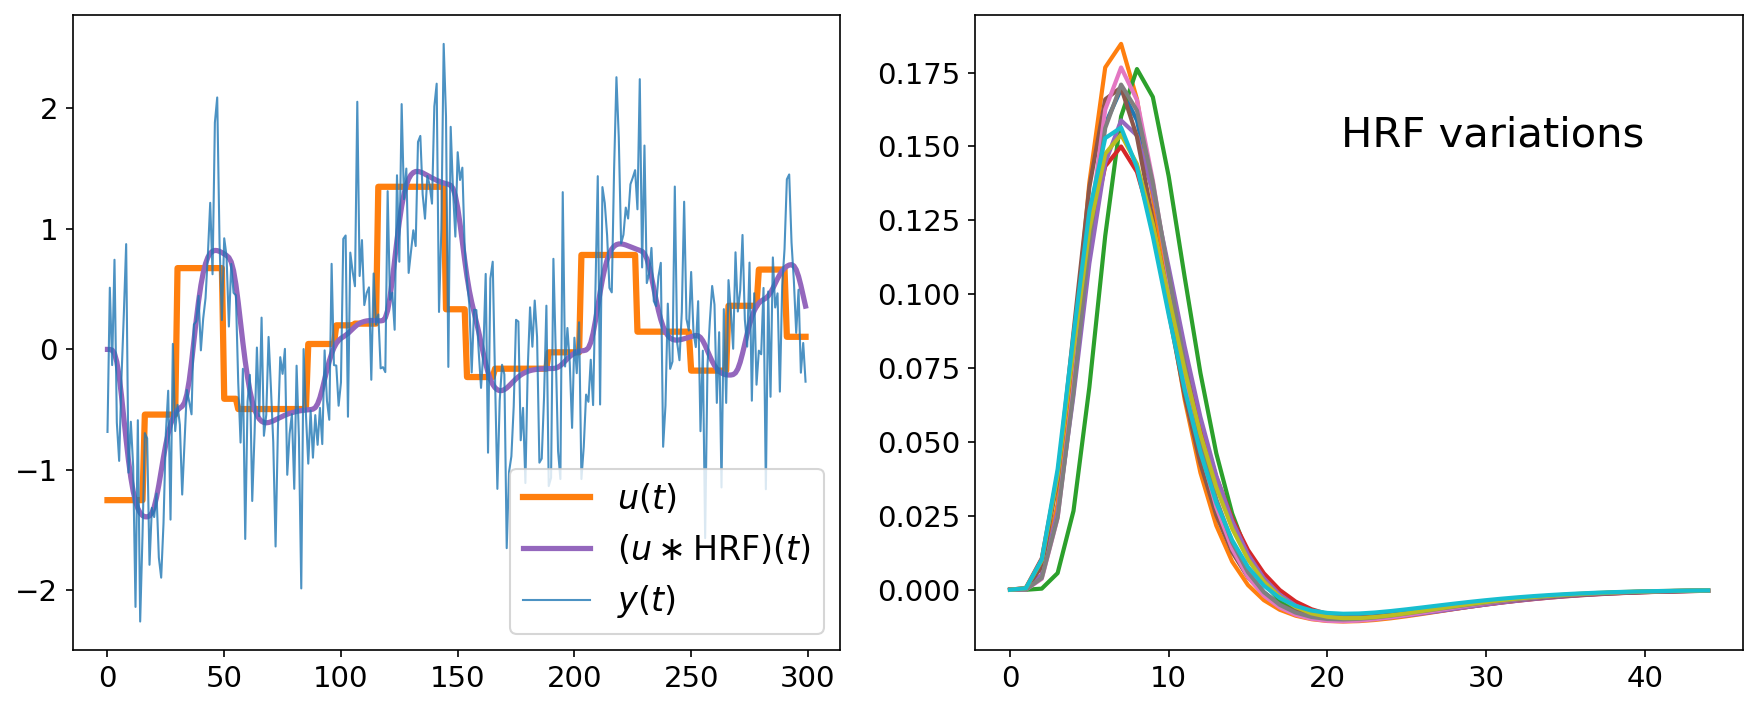

In [34]:
# from nilearn.glm.first_level import spm_hrf
# spm_hrf = spm_hrf(.72, oversampling=1, time_length=32.0, onset=0.) 

f, ax = plt.subplots(1, 2, figsize=(12, 5))

v = np.random.randint(0, 20)
ax[0].plot(y[v], color='tab:orange', label=r'$u(t)$', linewidth=3)
ax[0].plot(convolved[v], linewidth=2.5, color='tab:purple', label=r'$(u \ast \text{HRF})(t)$')
ax[0].plot(X[v], alpha=0.8, linewidth=1, color='tab:blue', label=r'$y(t)$')
ax[0].legend(fontsize=16)

t = np.arange(0, 32, .72)
for _ in range(10):
    hrf = spm_hrf_compat(
        t,
        peak_delay=np.random.uniform(5.5, 6.5),
        under_delay=np.random.uniform(15.5, 16.5),
        peak_disp=np.random.uniform(0.5, 1),
        under_disp=np.random.uniform(1.5, 1.8),
        p_u_ratio=max(6.5, np.random.normal(6, 0.5)),
        normalize=True
    )
    ax[1].plot(hrf, linewidth=2)
ax[1].text(40, 0.15, 'HRF variations', ha='right', size=20)
# ax[1].plot(spm_hrf, linewidth=2, c='r')


f.tight_layout()

f.savefig('report_results/sim_data.png')

# Results

## Finetuning

In [16]:
def load_winning_cnn_models():
    
    results_df = pd.read_csv(f'csv_logs/cnn_logs_W9.csv')
    results_df.loc[results_df.min_mse_val == results_df.min_mse_val.min()]
    best_models = pd.DataFrame([
        results_df.loc[results_df.study_name.str.contains('ALICEO2')].loc[lambda x: x['min_mse_val'].idxmin()], # Corrected to get the model with correct HRF oversampling
        results_df.loc[results_df.study_name.str.contains('MGL')].loc[lambda x: x['min_mse_val'].idxmin()],
    ])
    best_models_dict = get_best_models_dict(best_models)

    # Print winning models' names
    best_model_keys = list(best_models_dict.keys())
    print('### WINNING CNN MODELS ###\n')
    print(best_models_dict[best_model_keys[0]][0])
    print('\n')
    print(best_models_dict[best_model_keys[1]][0])
    print('\n')

    # Gather winning models
    winning_cnn_models = {
        "real": ['CNN (real)'] + best_models_dict[best_model_keys[1]][1:], # Real model key is located at idx=1 of best_model_keys
        "simulated": ['CNN (simulated)'] + best_models_dict[best_model_keys[0]][1:] # Simulated model key is located at idx=0 of best_model_keys
    }

    return winning_cnn_models
winning_cnn_models = load_winning_cnn_models()

### WINNING CNN MODELS ###

CNN_4L (ALICEO2)
7390 params
(K1=70, K2=30, K3=35, K4=53, F1=9, F2=10, F3=10)
MSE_TV (a=30.0000, l=0.0001)


CNN_4L (MGL)
5797 params
(K1=29, K2=76, K3=79, K4=85, F1=5, F2=6, F3=6)
MSE_TV (a=30.6089, l=0.0000)




In [17]:
from tools.analysis import get_best_models_dict
def load_winning_ae_models():
    results_df = pd.read_csv('csv_logs/ae_logs_W9.csv')
    results_df = results_df[
        results_df['study_name'].apply(lambda s: int(s[-15:-7]) >= 20250424)
    ]
    sim_length, real_length = 300, 316
    results_df['signal_length'] = [sim_length if 'ALICE' in row.study_name else real_length for _, row in results_df.iterrows()]
    results_df = results_df.loc[results_df.study_name.str.contains('ALICE_')==False] # Correction to get the simulated model trained on corrected sim_data (HRF oversampling error)
    best_models_dict = get_best_models_dict(results_df)

    # Print winning models' names
    best_model_keys = list(best_models_dict.keys())
    print('### WINNING AE MODELS ###\n')
    print(best_models_dict[best_model_keys[0]][0])
    print('\n')
    print(best_models_dict[best_model_keys[1]][0])
    print('\n')

    # Gather winning models
    winning_ae_models = {
        "real": ['AE (real)'] + best_models_dict[best_model_keys[0]][1:],
        "simulated": ['AE (simulated)'] + best_models_dict[best_model_keys[1]][1:]
    }

    return winning_ae_models
winning_ae_models = load_winning_ae_models()

### WINNING AE MODELS ###

AutoEncoder(CNN_4L) (MGL)
207018 params
(C=4, F=7, K=19, D=0.2)
MSE


AutoEncoder(CNN_4L) (ALICEO2)
209823 params
(C=4, F=8, K=13, D=0.1)
MSE




In [3]:
def format_test_df(data_dict):
    renamed_dfs = []
    for key, df in data_dict.items():
        renamed = df.rename(columns={"metric": f"MSE ({key})", "var": f"var ({key})"})
        renamed_dfs.append(renamed)

    # Merge all dataframes on the 'model' column
    master_df = renamed_dfs[0]
    for df in renamed_dfs[1:]:
        master_df = master_df.merge(df, on="model", how="outer")
    
    master_df['pretraining_dataset'] = master_df['model'].str.contains('real').map({True: 'real', False: 'simulated'})
    master_df = master_df.sort_values(by='pretraining_dataset', ascending=True)
    master_df['model'] = master_df['model'].str.replace(r'\s*\(real\)', '', regex=True)
    master_df['model'] = master_df['model'].str.replace(r'\s*\(simulated\)', '', regex=True)
    master_df.set_index(['pretraining_dataset', 'model'], inplace=True)
    master_df.index.names = ['Pretraining dataset', 'Model']

    pairs = [
        ('MSE (simulated)', 'var (simulated)'),
        ('MSE (real)', 'var (real)'),
        ('MSE (motor)', 'var (motor)'),
        ('MSE (language)', 'var (language)'),
        ('MSE (gambling)', 'var (gambling)'),
        ('MSE (emotion)', 'var (emotion)'),
        ('MSE (wm)', 'var (wm)')
    ]

    # Overwrite MSE columns with formatted string
    for mse_col, var_col in pairs:
        master_df[mse_col] = master_df.apply(lambda row: f"{row[mse_col]:.4f} ± {row[var_col]:.4f}", axis=1)
    master_df = master_df.drop(columns=[var for _, var in pairs])

    return master_df

In [2]:
test_data = {
    # 'simulated': torch.load('datasets/simulated_data_aliceO2_300m.pt')['test'],
    'real': torch.load('datasets/real_data_MGL_080808.pt')['test'],
    # 'motor': get_real_data_split('motor', augmentation=False, final_length=316)['test'],
    # 'language': get_real_data_split('language', augmentation=False, final_length=316)['test'],
    # 'gambling': get_real_data_split('gambling', augmentation=False, final_length=316)['test'],
    # 'emotion': get_real_data_split('emotion', augmentation=False, final_length=316, for_test=True)['test'],
    # 'wm': get_real_data_split('wm', augmentation=False, final_length=316, for_test=True)['test']
}

### CNN

In [5]:
cnn_FT_dict = pickle_load(f'final_models/cnn_finetuned.pkl')

cnn_test_df_dict = {}
for data_type, dataset in tqdm(test_data.items()):
    cnn_test_df_dict[data_type] = compute_test_metric(cnn_FT_dict, dataset, device="cpu")

formatted_cnn_df = format_test_df(cnn_test_df_dict)
formatted_cnn_df.to_csv("report_results/cnn_master_mse.csv")

100%|█████████████████████████████████████████████| 7/7 [02:51<00:00, 24.49s/it]


In [3]:
formatted_cnn_df = pd.read_csv("report_results/cnn_master_mse.csv", index_col=[0, 1])
formatted_cnn_df
# print(formatted_cnn_df.to_latex())

MSE (simulated)       MSE (real)  \
Pretraining dataset Model                                                  
real                CNN                 0.1356 ± 0.0001  0.0679 ± 0.0012   
                    CNN\nFT adapter     0.0919 ± 0.0000  0.1500 ± 0.0043   
                    CNN\nFT adapter2    0.0794 ± 0.0000  0.1548 ± 0.0012   
                    CNN\nFT last_layer  0.0978 ± 0.0000  0.1392 ± 0.0056   
simulated           CNN                 0.0606 ± 0.0000  0.1534 ± 0.0035   
                    CNN\nFT adapter     0.0961 ± 0.0000  0.0917 ± 0.0009   
                    CNN\nFT adapter2    0.1019 ± 0.0000  0.0832 ± 0.0012   
                    CNN\nFT last_layer  0.0955 ± 0.0000  0.1000 ± 0.0011   

                                            MSE (motor)   MSE (language)  \
Pretraining dataset Model                                                  
real                CNN                 0.0616 ± 0.0002  0.1070 ± 0.0007   
                    CNN\nFT adapter     0.2064 ± 0.0052  0.1498 ± 0.0010   
                    CNN\nFT adapter2    0.1571 ± 0.0018  0.1667 ± 0.0012   
                    CNN\nFT last_layer  0.1887 ± 0.0091  0.1509 ± 0.0012   
simulated           CNN                 0.1696 ± 0.0049  0.1813 ± 0.0022   
                    CNN\nFT adapter     0.0957 ± 0.0003  0.1166 ± 0.0008   
                    CNN\nFT adapter2    0.0854 ± 0.0002  0.1165 ± 0.0009   
                    CNN\nFT last_layer  0.1105 ± 0.0007  0.1203 ± 0.0010   

                                         MSE (gambling)    MSE (emotion)  \
Pretraining dataset Model                                                  
real                CNN                 0.0350 ± 0.0002  0.1100 ± 0.0010   
                    CNN\nFT adapter     0.0937 ± 0.0002  0.1615 ± 0.0022   
                    CNN\nFT adapter2    0.1405 ± 0.0004  0.2363 ± 0.0031   
                    CNN\nFT last_layer  0.0781 ± 0.0002  0.1433 ± 0.0015   
simulated           CNN                 0.1091 ± 0.0004  0.1320 ± 0.0015   
                    CNN\nFT adapter     0.0626 ± 0.0001  0.1001 ± 0.0010   
                    CNN\nFT adapter2    0.0476 ± 0.0001  0.1115 ± 0.0011   
                    CNN\nFT last_layer  0.0691 ± 0.0001  0.1077 ± 0.0012   

                                               MSE (wm)  
Pretraining dataset Model                                
real                CNN                 0.1054 ± 0.0004  
                    CNN\nFT adapter     0.1163 ± 0.0004  
                    CNN\nFT adapter2    0.1259 ± 0.0005  
                    CNN\nFT last_layer  0.1167 ± 0.0005  
simulated           CNN                 0.1296 ± 0.0008  
                    CNN\nFT adapter     0.0950 ± 0.0003  
                    CNN\nFT adapter2    0.0901 ± 0.0003  
                    CNN\nFT last_layer  0.0964 ± 0.0003

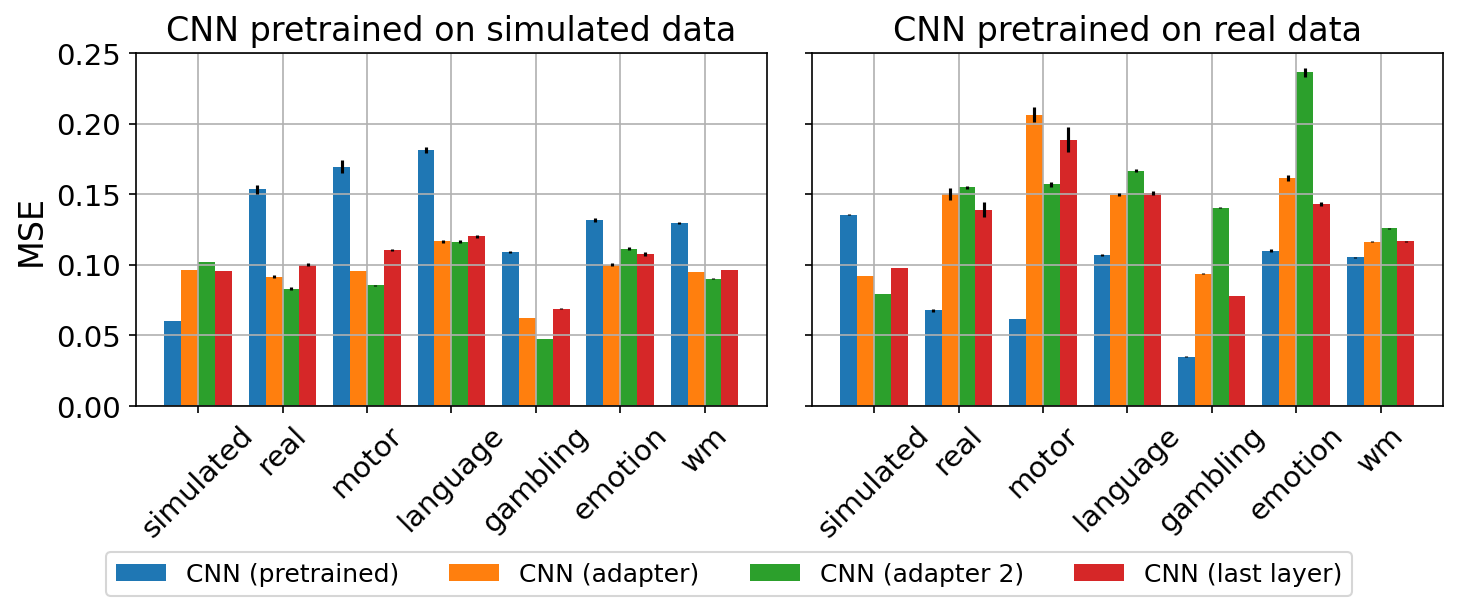

In [35]:
formatted_cnn_df = pd.read_csv("report_results/cnn_master_mse.csv", index_col=[0, 1])

new_index = formatted_cnn_df.index.to_frame()
new_index['Model'] = new_index['Model'].replace({
    'CNN': 'CNN (pretrained)',
    'CNN\nFT adapter': 'CNN (adapter)',
    'CNN\nFT adapter2': 'CNN (adapter 2)',
    'CNN\nFT last_layer': 'CNN (last layer)'
})
formatted_cnn_df.index = pd.MultiIndex.from_frame(new_index)
ticks = [col[5:-1] for col in formatted_cnn_df.columns]
n = len(ticks)
# colors = ['blue', 'lightgrey', 'red', 'darkgrey']

f, ax = plt.subplots(1, 2, figsize=(10, 4))

for i, data_type in enumerate(['simulated', 'real']):
    for j, model in enumerate(formatted_cnn_df.index.get_level_values(1).unique()):
        mse = [float(value[:6]) for value in formatted_cnn_df.loc[(data_type, model)]]
        var = [float(value[9:]) for value in formatted_cnn_df.loc[(data_type, model)]]
        ax[i].bar(np.arange(n)-0.3+j*0.2, mse, yerr=var, width=0.2, label=model)
    ax[i].set_xticks(np.arange(n))
    ax[i].set_xticklabels(ticks, rotation=45)
    ax[i].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax[i].set_ylim([0, 0.25])
    ax[i].grid()
    ax[i].set_title(f'CNN pretrained on {data_type} data')
ax[0].set_ylabel('MSE')
ax[1].set_yticklabels([])
handles, labels = ax[0].get_legend_handles_labels()
f.legend(handles, labels, loc='lower center', fontsize=12, ncol=4, bbox_to_anchor=(0.5, -0.05), ncols=4)
f.tight_layout()

# f.savefig('report_results/cnn_ft.png', bbox_inches='tight')

### AE

In [10]:
del cnn_FT_dict
ae_FT_dict = pickle_load(f'final_models/ae_finetuned.pkl')

ae_test_df_dict = {}
for data_type, dataset in tqdm(test_data.items()):
    ae_test_df_dict[data_type] = compute_test_metric(ae_FT_dict, dataset, device="cpu")

formatted_ae_df = format_test_df(ae_test_df_dict)
formatted_ae_df.to_csv("report_results/ae_master_mse.csv")

100%|█████████████████████████████████████████████| 7/7 [02:27<00:00, 21.05s/it]


In [4]:
formatted_ae_df = pd.read_csv("report_results/ae_master_mse.csv", index_col=[0, 1])
formatted_ae_df
# print(formatted_ae_df.to_latex())

MSE (simulated)       MSE (real)  \
Pretraining dataset Model                                             
real                AE             0.2011 ± 0.0001  0.0680 ± 0.0012   
                    AE\nFT ED_LDM  0.1797 ± 0.0001  0.1075 ± 0.0009   
                    AE\nFT LDM     0.0991 ± 0.0001  0.1501 ± 0.0034   
simulated           AE             0.0802 ± 0.0000  0.1944 ± 0.0050   
                    AE\nFT ED_LDM  0.1578 ± 0.0001  0.1423 ± 0.0013   
                    AE\nFT LDM     0.1414 ± 0.0001  0.0635 ± 0.0015   

                                       MSE (motor)   MSE (language)  \
Pretraining dataset Model                                             
real                AE             0.0587 ± 0.0002  0.1062 ± 0.0010   
                    AE\nFT ED_LDM  0.0994 ± 0.0004  0.1336 ± 0.0011   
                    AE\nFT LDM     0.1494 ± 0.0017  0.2028 ± 0.0028   
simulated           AE             0.2152 ± 0.0068  0.2268 ± 0.0034   
                    AE\nFT ED_LDM  0.1471 ± 0.0010  0.1532 ± 0.0020   
                    AE\nFT LDM     0.0504 ± 0.0001  0.1062 ± 0.0013   

                                    MSE (gambling)    MSE (emotion)  \
Pretraining dataset Model                                             
real                AE             0.0388 ± 0.0001  0.1309 ± 0.0013   
                    AE\nFT ED_LDM  0.0895 ± 0.0002  0.1307 ± 0.0013   
                    AE\nFT LDM     0.0981 ± 0.0003  0.1336 ± 0.0013   
simulated           AE             0.1411 ± 0.0006  0.1787 ± 0.0022   
                    AE\nFT ED_LDM  0.1265 ± 0.0005  0.1369 ± 0.0014   
                    AE\nFT LDM     0.0338 ± 0.0003  0.1242 ± 0.0013   

                                          MSE (wm)  
Pretraining dataset Model                           
real                AE             0.1858 ± 0.0012  
                    AE\nFT ED_LDM  0.1698 ± 0.0008  
                    AE\nFT LDM     0.1418 ± 0.0007  
simulated           AE             0.1619 ± 0.0010  
                    AE\nFT ED_LDM  0.1426 ± 0.0005  
                    AE\nFT LDM     0.1113 ± 0.0003

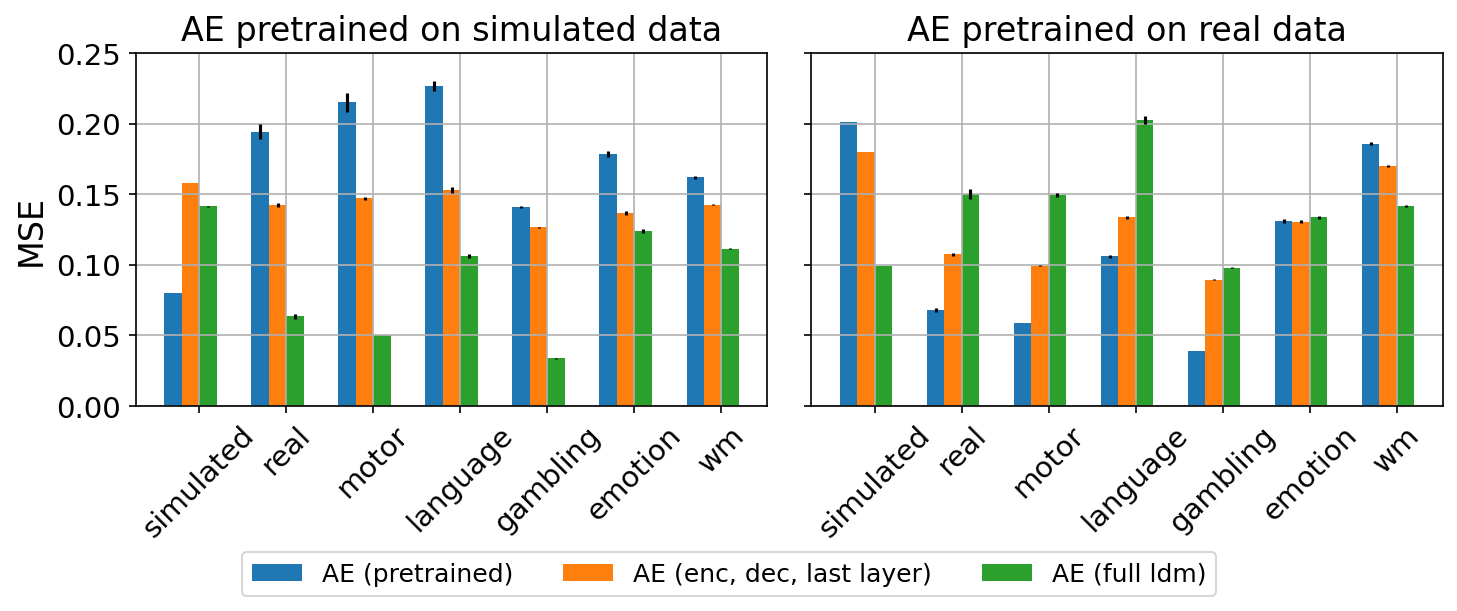

In [33]:
formatted_ae_df = pd.read_csv("report_results/ae_master_mse.csv", index_col=[0, 1])

new_index = formatted_ae_df.index.to_frame()
new_index['Model'] = new_index['Model'].replace({
    'AE': 'AE (pretrained)',
    'AE\nFT ED_LDM': 'AE (enc, dec, last layer)',
    'AE\nFT LDM': 'AE (full ldm)',
})
formatted_ae_df.index = pd.MultiIndex.from_frame(new_index)
ticks = [col[5:-1] for col in formatted_ae_df.columns]
n = len(ticks)

f, ax = plt.subplots(1, 2, figsize=(10, 4))

for i, data_type in enumerate(['simulated', 'real']):
    for j, model in enumerate(formatted_ae_df.index.get_level_values(1).unique()):
        mse = [float(value[:6]) for value in formatted_ae_df.loc[(data_type, model)]]
        var = [float(value[9:]) for value in formatted_ae_df.loc[(data_type, model)]]
        ax[i].bar(np.arange(n)-0.3+j*0.2, mse, yerr=var, width=0.2, label=model)
    ax[i].set_xticks(np.arange(n))
    ax[i].set_xticklabels(ticks, rotation=45)
    ax[i].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax[i].set_ylim([0, 0.25])
    ax[i].grid()
    ax[i].set_title(f'AE pretrained on {data_type} data')
ax[0].set_ylabel('MSE')
ax[1].set_yticklabels([])
handles, labels = ax[0].get_legend_handles_labels()
f.legend(handles, labels, loc='lower center', fontsize=12, ncol=4, bbox_to_anchor=(0.5, -0.05), ncols=4)
f.tight_layout()

# f.savefig('report_results/ae_ft.png', bbox_inches='tight')

### Reduced MSE table & plot

In [3]:
formatted_cnn_df = pd.read_csv("report_results/cnn_master_mse.csv", index_col=[0, 1])
formatted_ae_df = pd.read_csv("report_results/ae_master_mse.csv", index_col=[0, 1])

reduced_table = pd.concat([
    formatted_cnn_df.loc[[('simulated', 'CNN'), ('simulated', 'CNN\nFT adapter2')]],
    formatted_ae_df.loc[[('simulated', 'AE'), ('simulated', 'AE\nFT LDM')]]
]).droplevel(0, axis=0).T.rename_axis('MSE', axis=1)
reduced_table.index = reduced_table.index.map(lambda x: x[5:-1])


reduced_table = reduced_table.rename(columns={
    'CNN': 'CNN (pretrained)',
    'CNN\nFT adapter2': 'CNN (finetuned)',
    'AE': 'AE (pretrained)',
    'AE\nFT LDM': 'AE (finetuned)'
})

# print(reduced_table.to_latex(columns=['CNN (pretrained)', 'CNN (finetuned)']))
# print(reduced_table.to_latex(columns=['AE (pretrained)', 'AE (finetuned)']))
# print(reduced_table.to_latex(columns=['CNN (finetuned)', 'AE (finetuned)']))
# print(reduced_table.to_latex())
reduced_table

MSE,CNN (pretrained),CNN (finetuned),AE (pretrained),AE (finetuned)
simulated,0.0606 ± 0.0000,0.1019 ± 0.0000,0.0802 ± 0.0000,0.1414 ± 0.0001
real,0.1534 ± 0.0035,0.0832 ± 0.0012,0.1944 ± 0.0050,0.0635 ± 0.0015
motor,0.1696 ± 0.0049,0.0854 ± 0.0002,0.2152 ± 0.0068,0.0504 ± 0.0001
language,0.1813 ± 0.0022,0.1165 ± 0.0009,0.2268 ± 0.0034,0.1062 ± 0.0013
gambling,0.1091 ± 0.0004,0.0476 ± 0.0001,0.1411 ± 0.0006,0.0338 ± 0.0003
emotion,0.1320 ± 0.0015,0.1115 ± 0.0011,0.1787 ± 0.0022,0.1242 ± 0.0013
wm,0.1296 ± 0.0008,0.0901 ± 0.0003,0.1619 ± 0.0010,0.1113 ± 0.0003


In [14]:
formatted_ae_df.loc[('real', 'AE')][[0, 2, 3, 4, 5, 6]]

/tmp/ipykernel_4036173/773177646.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  formatted_ae_df.loc[('real', 'AE')][[0, 2, 3, 4, 5, 6]]


MSE (simulated)    0.2011 ± 0.0001
MSE (motor)        0.0587 ± 0.0002
MSE (language)     0.1062 ± 0.0010
MSE (gambling)     0.0388 ± 0.0001
MSE (emotion)      0.1309 ± 0.0013
MSE (wm)           0.1858 ± 0.0012
Name: (real, AE), dtype: object

/tmp/ipykernel_4036173/3529588789.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [float(value[:6]) for value in reduced_table[f'{model_type} ({training_type})'][[0, 2, 3, 4, 5, 6]]],
/tmp/ipykernel_4036173/3529588789.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yerr=[float(value[9:]) for value in reduced_table[f'{model_type} ({training_type})'][[0, 2, 3, 4, 5, 6]]],
/tmp/ipykernel_4036173/3529588789.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value b

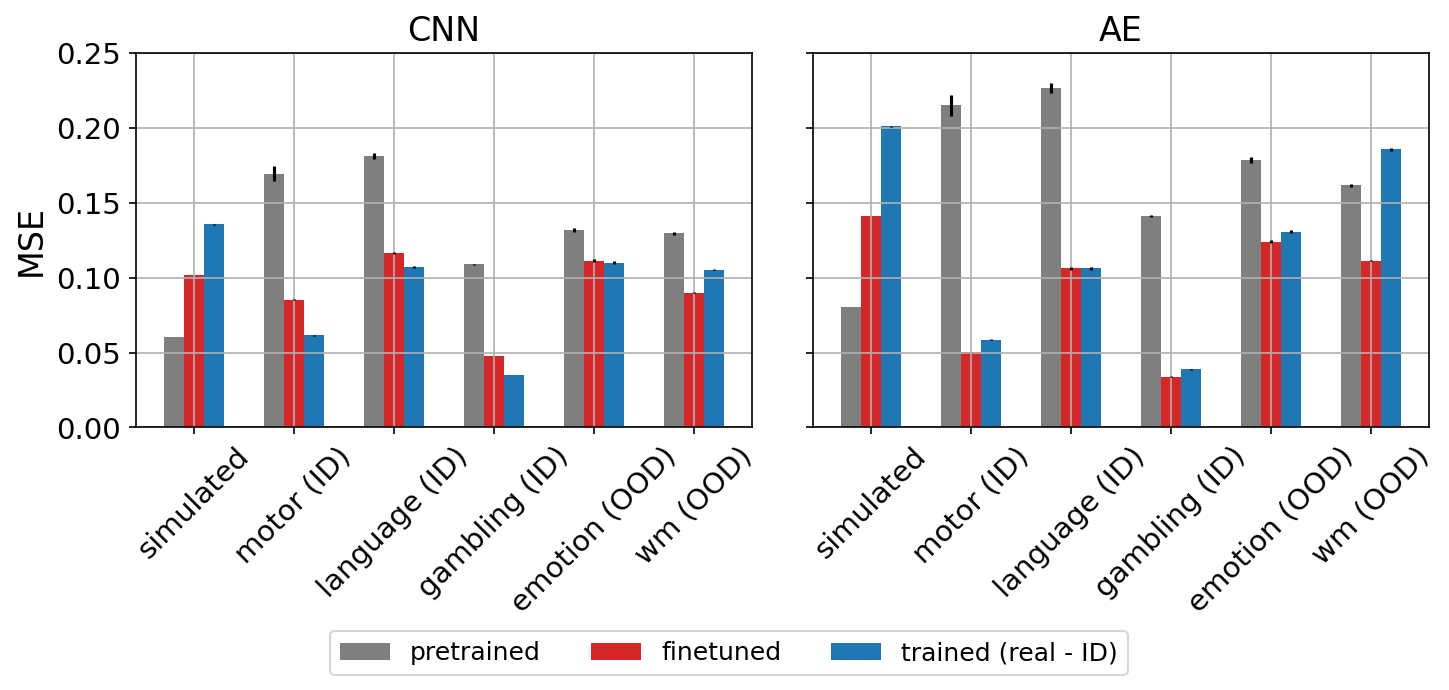

In [27]:
ticks = list(['simulated', 'motor (ID)', 'language (ID)', 'gambling (ID)', 'emotion (OOD)', 'wm (OOD)'])
n = len(ticks)

f, ax = plt.subplots(1, 2, figsize=(10, 4.5))

for i, model_type in enumerate(['CNN', 'AE']):
    for j, (training_type, color) in enumerate(zip(['pretrained', 'finetuned'], ['tab:grey', 'tab:red'])):
        ax[i].bar(
            np.arange(n)-0.2+j*0.2,
            [float(value[:6]) for value in reduced_table[f'{model_type} ({training_type})'][[0, 2, 3, 4, 5, 6]]],
            yerr=[float(value[9:]) for value in reduced_table[f'{model_type} ({training_type})'][[0, 2, 3, 4, 5, 6]]],
            width=0.2,
            label=training_type,
            color=color
        )
    ax[i].set_title(model_type)
    ax[i].set_xticks(np.arange(n))
    ax[i].set_xticklabels(ticks, rotation=45)
    ax[i].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax[i].set_ylim([0, 0.25])
    ax[i].grid()

ax[0].bar(
    np.arange(n)+0.2,
    [float(value[:6]) for value in formatted_cnn_df.loc[('real', 'CNN')][[0, 2, 3, 4, 5, 6]]],
    yerr=[float(value[9:]) for value in formatted_cnn_df.loc[('real', 'CNN')][[0, 2, 3, 4, 5, 6]]],
    width=0.2,
    color='tab:blue',
    label='trained (real - ID)'
)
ax[1].bar(
    np.arange(n)+0.2,
    [float(value[:6]) for value in formatted_ae_df.loc[('real', 'AE')][[0, 2, 3, 4, 5, 6]]],
    yerr=[float(value[9:]) for value in formatted_ae_df.loc[('real', 'AE')][[0, 2, 3, 4, 5, 6]]],
    width=0.2,
    color='tab:blue'
)

ax[0].set_ylabel('MSE')
ax[1].set_yticklabels([])
handles, labels = ax[0].get_legend_handles_labels()
f.legend(handles, labels, loc='lower center', fontsize=12, ncol=3, bbox_to_anchor=(0.5, -0.05), ncols=4)
f.tight_layout()

### Inference

In [32]:
cnn_FT_dict = pickle_load(f'final_models/cnn_finetuned.pkl')
ae_FT_dict = pickle_load(f'final_models/ae_finetuned.pkl')

final_models_dict = {
    'CNN (pretrained)': cnn_FT_dict['simulated'][1],
    'CNN (finetuned)': cnn_FT_dict['simulated_ft_adapter2'][1],
    'AE (pretrained)': ae_FT_dict['simulated'][1],
    'AE (finetuned)': ae_FT_dict['simulated_ft_LDM'][1]
}

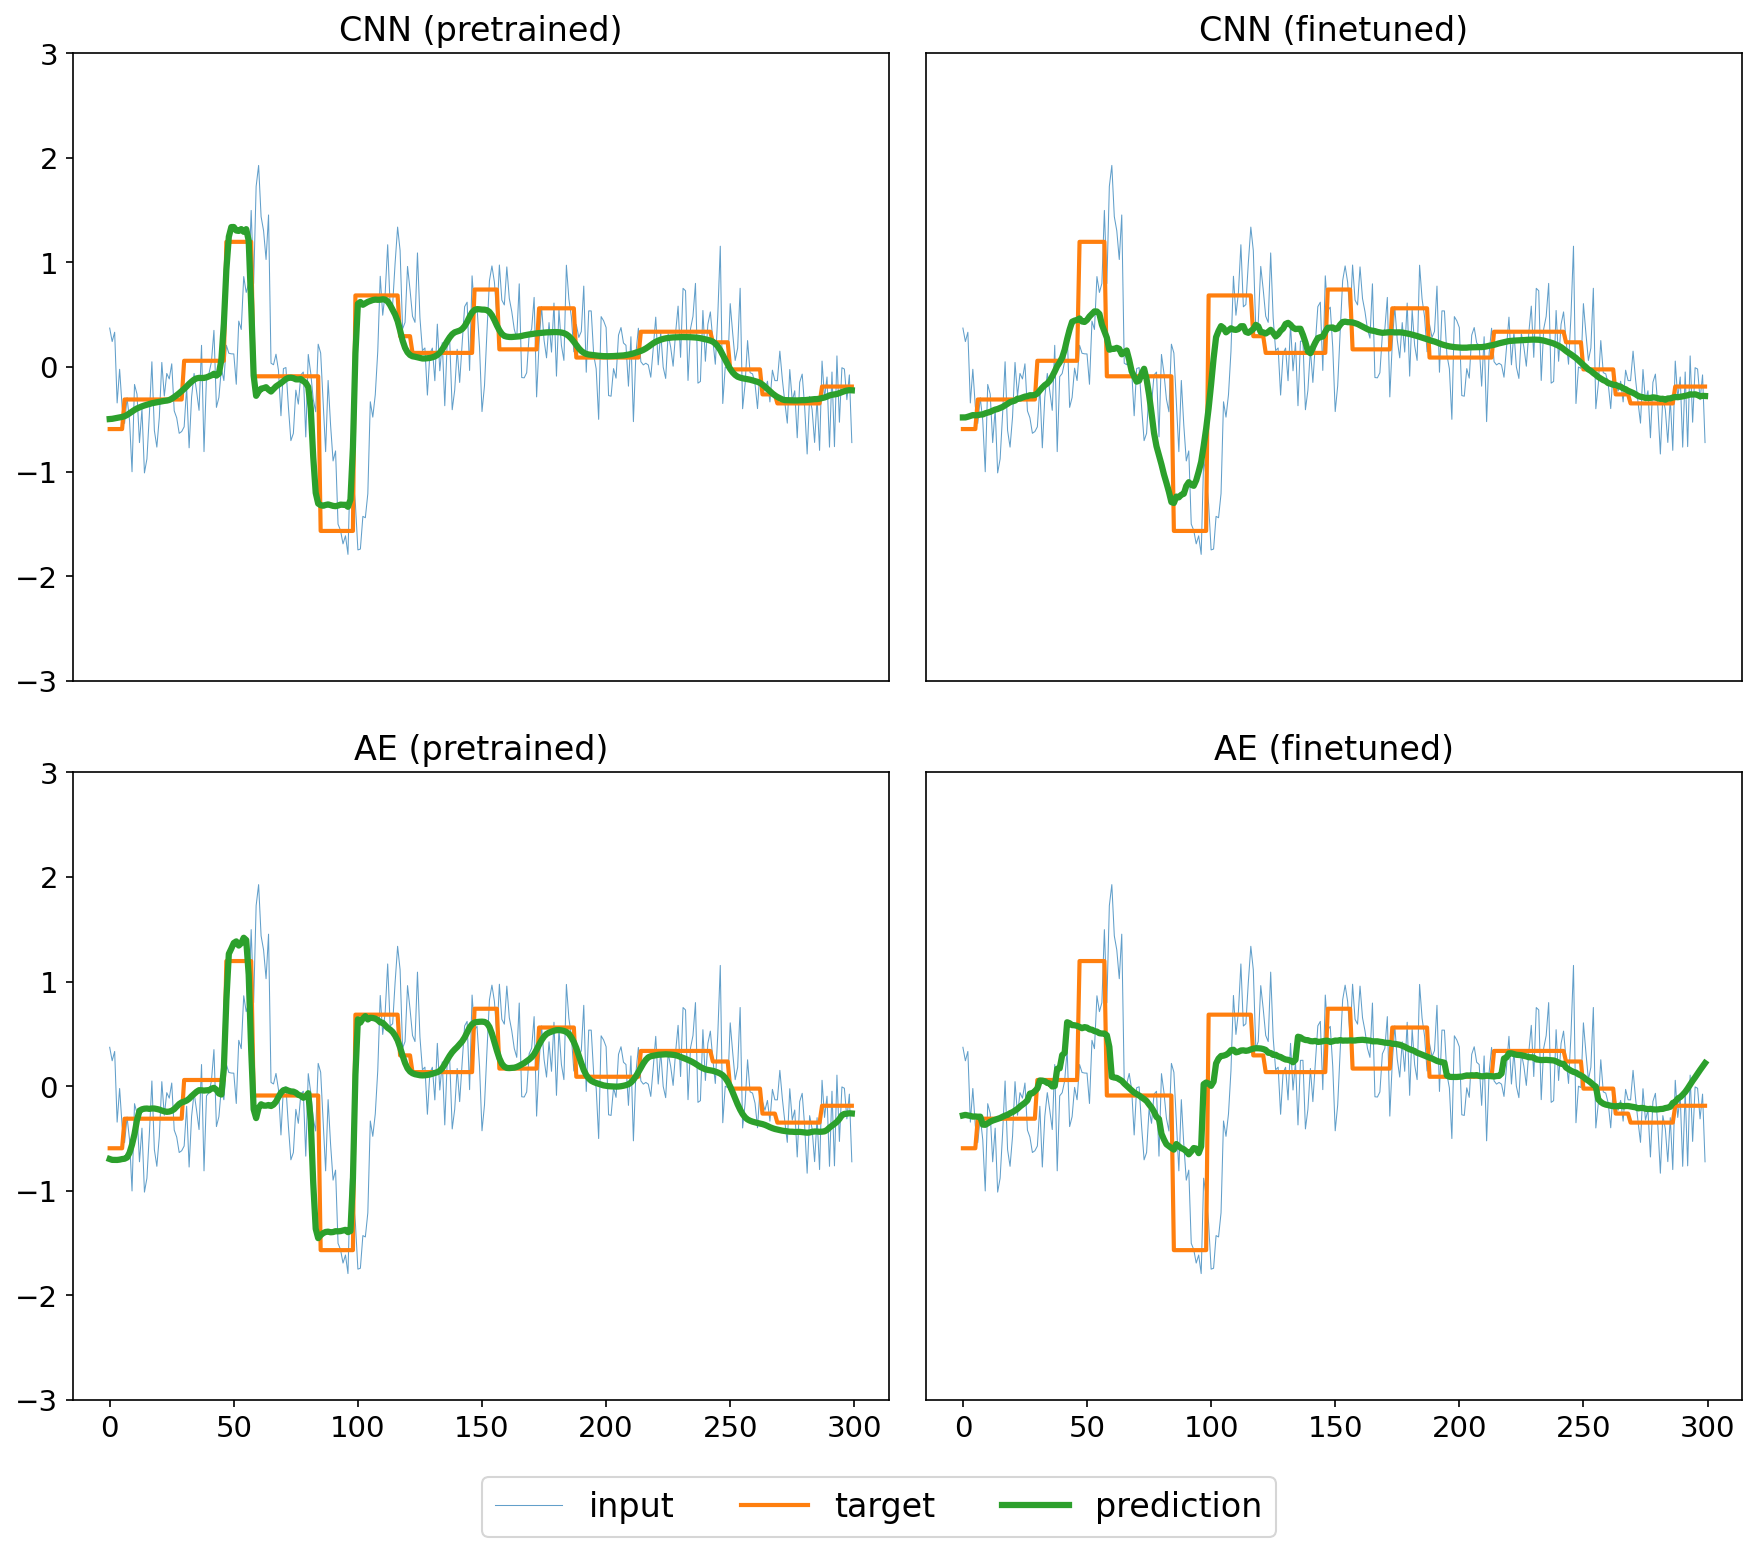

In [ ]:
def plot_sample_final_models(final_models_dict, dataset):

    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    ax = ax.flatten()
    input_plot_args = {'linewidth': 0.5, 'alpha': 0.7, 'label': 'input', 'c': 'tab:blue'}
    target_plot_args = {'linewidth': 2, 'label': 'target', 'c': 'tab:orange'}
    prediction_plot_args = {'linewidth': 3, 'label': 'prediction', 'c': 'tab:green'}

    v = np.random.randint(10000)
    X, y = dataset[v]
    X = X.unsqueeze(0).unsqueeze(-1)

    for i, (model_name, model) in enumerate(final_models_dict.items()):

        model = model.to('cpu')
        if type(model) == AutoEncoderDeconvolution:
            padding = (model.signal_length - X.shape[1]) / 2
            X_padded = F.pad(X, (0, 0, int(np.ceil(padding)), int(np.floor(padding))), mode='constant', value=0)
            y_padded = F.pad(y, (int(np.ceil(padding)), int(np.floor(padding))), mode='constant', value=0)
            _, _, prediction = model(X_padded)
            ax[i].plot(X_padded.squeeze(), **input_plot_args)
            ax[i].plot(y_padded, **target_plot_args)
        else:
            prediction = model(X)
            ax[i].plot(X.squeeze(), **input_plot_args)
            ax[i].plot(y, **target_plot_args)
        prediction = prediction.detach().squeeze()

        ax[i].plot(prediction, **prediction_plot_args)
        ax[i].set_title(model_name)

        ax[i].set_ylim([-3, 3])

    ax[1].set_yticks([], [])
    ax[3].set_yticks([], [])
    ax[0].set_xticks([], [])
    ax[1].set_xticks([], [])
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), fontsize=16, ncol=len(handles))
    fig.tight_layout()

    return fig

# f_gambling = plot_sample_final_models(final_models_dict, test_data['gambling'])
# f_gambling.savefig('report_results/inference_gambling.png', bbox_inches='tight')

# f_wm = plot_sample_final_models(final_models_dict, test_data['wm'])
# f_wm.savefig('report_results/inference_wm.png', bbox_inches='tight')

# f_simulated = plot_sample_final_models(final_models_dict, test_data['simulated'])
# f_simulated.savefig('report_results/inference_simulated.png', bbox_inches='tight')

## Mixed data training

In [4]:
from torch.utils.data import ConcatDataset

real_data = torch.load('datasets/real_data_MGL_000000.pt')
sim_data = torch.load('datasets/simulated_data_aliceO2_300m.pt')
emotion_data = get_real_data_split('emotion', augmentation=False, final_length=316, for_test=True)['test']
wm_data = get_real_data_split('wm', augmentation=False, final_length=316, for_test=True)['test']
ood_data = ConcatDataset([emotion_data, wm_data])

test_loader_real = DataLoader(real_data['test'])
test_loader_sim = DataLoader(sim_data['test'])
ood_loader = DataLoader(ood_data)

Preprocessing data as test set:


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:17<00:00,  5.79it/s]


Preprocessing data as test set:


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:06<00:00,  4.56it/s]


### CNN

In [4]:
models_dict_CNN = pickle_load('final_models/mixed_models_CNN_4L.pkl')['models_dict']

In [ ]:
test_mse_dict = {'prop_real': [], 'mse_real': [], 'var_real': [], 'mse_sim': [], 'var_sim': [], 'mse_ood': [], 'var_ood': []}
for prop_real, model in tqdm(models_dict_CNN.items()):

    mse_real, var_real = test_model(test_loader_real, model)
    mse_sim, var_sim = test_model(test_loader_sim, model)
    mse_ood, var_ood = test_model(ood_loader, model)

    test_mse_dict['prop_real'].append(prop_real)
    test_mse_dict['mse_real'].append(mse_real)
    test_mse_dict['var_real'].append(var_real)
    test_mse_dict['mse_sim'].append(mse_sim)
    test_mse_dict['var_sim'].append(var_sim)
    test_mse_dict['mse_ood'].append(mse_ood)
    test_mse_dict['var_ood'].append(var_ood)

test_mse_df_CNN = pd.DataFrame(test_mse_dict)
test_mse_df_CNN.to_csv("report_results/mixed_mse_cnn.csv")

100%|████████████████████████████████████████████| 7/7 [29:08<00:00, 249.79s/it]


### AE

In [22]:
models_dict_AE = pickle_load('final_models/mixed_models_AutoEncoderDeconvolution.pkl')['models_dict']

In [36]:
test_mse_dict = {'prop_real': [], 'mse_real': [], 'var_real': [], 'mse_sim': [], 'var_sim': [], 'mse_ood': [], 'var_ood': []}
for prop_real, model in tqdm(models_dict_AE.items()):

    mse_real, var_real = test_model(test_loader_real, model)
    mse_sim, var_sim = test_model(test_loader_sim, model)
    mse_ood, var_ood = test_model(ood_loader, model)

    test_mse_dict['prop_real'].append(prop_real)
    test_mse_dict['mse_real'].append(mse_real)
    test_mse_dict['var_real'].append(var_real)
    test_mse_dict['mse_sim'].append(mse_sim)
    test_mse_dict['var_sim'].append(var_sim)
    test_mse_dict['mse_ood'].append(mse_ood)
    test_mse_dict['var_ood'].append(var_ood)

test_mse_df_AE = pd.DataFrame(test_mse_dict)
test_mse_df_AE.to_csv("report_results/mixed_mse_ae.csv")

100%|████████████████████████████████████████████| 7/7 [48:54<00:00, 419.22s/it]


### Plot

In [28]:
test_mse_df_AE = pd.read_csv("report_results/mixed_mse_ae.csv", index_col=[0])
test_mse_df_CNN = pd.read_csv("report_results/mixed_mse_cnn.csv", index_col=[0])
mixed_data_results = {'CNN': test_mse_df_CNN, 'AE': test_mse_df_AE}

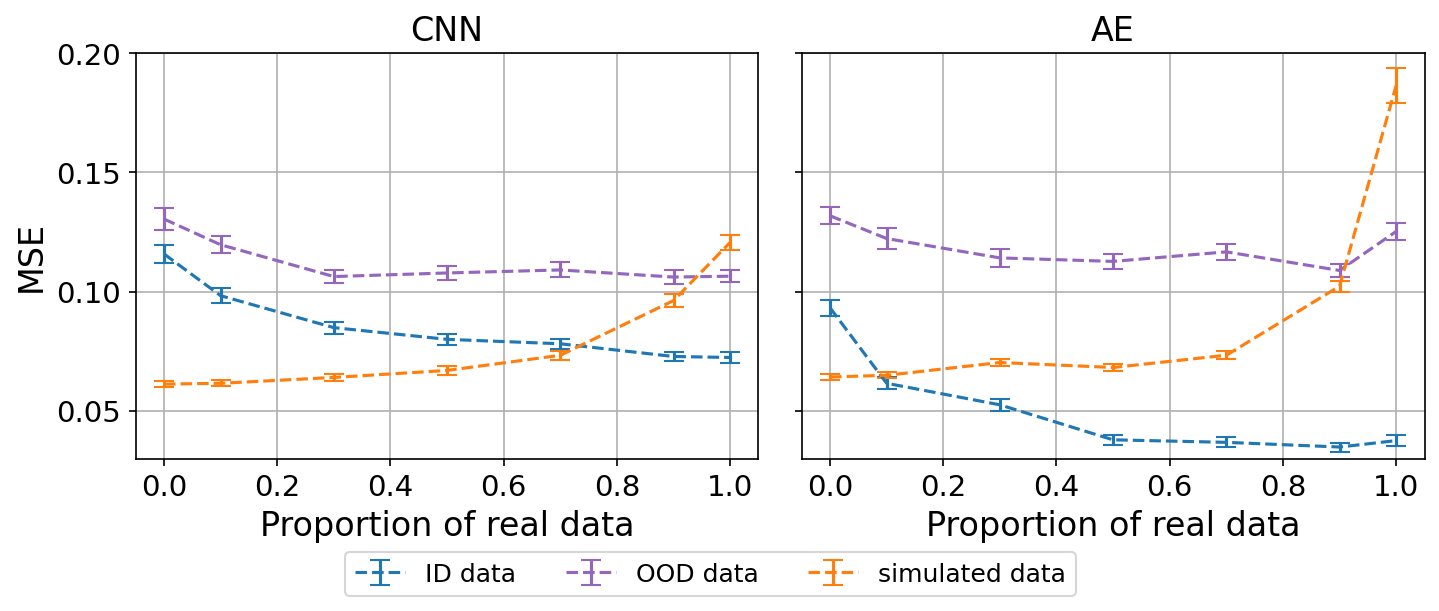

In [30]:
f, ax = plt.subplots(1, 2, figsize=(10, 4))

for i, (model_type, df) in enumerate(mixed_data_results.items()):
    ax[i].errorbar(df.prop_real, df.mse_real, yerr=df.var_real, capsize=5, label='ID data', c='tab:blue', linestyle='--')
    ax[i].errorbar(df.prop_real, df.mse_ood, yerr=df.var_ood, capsize=5, label='OOD data', c='tab:purple', linestyle='--')
    ax[i].errorbar(df.prop_real, df.mse_sim, yerr=df.var_sim, capsize=5, label='simulated data', c='tab:orange', linestyle='--')
    ax[i].set_xlabel('Proportion of real data')
    ax[i].set_title(f'{model_type}')
    ax[i].grid()
    ax[i].set_ylim([0.03, 0.2])

ax[0].set_ylabel('MSE')
ax[1].set_yticklabels([])
handles, labels = ax[0].get_legend_handles_labels()
f.legend(handles, labels, loc='lower center', fontsize=12, ncol=4, bbox_to_anchor=(0.5, -0.05), ncols=4)
f.tight_layout()

f.savefig("report_results/mse_mixed.png", bbox_inches='tight')

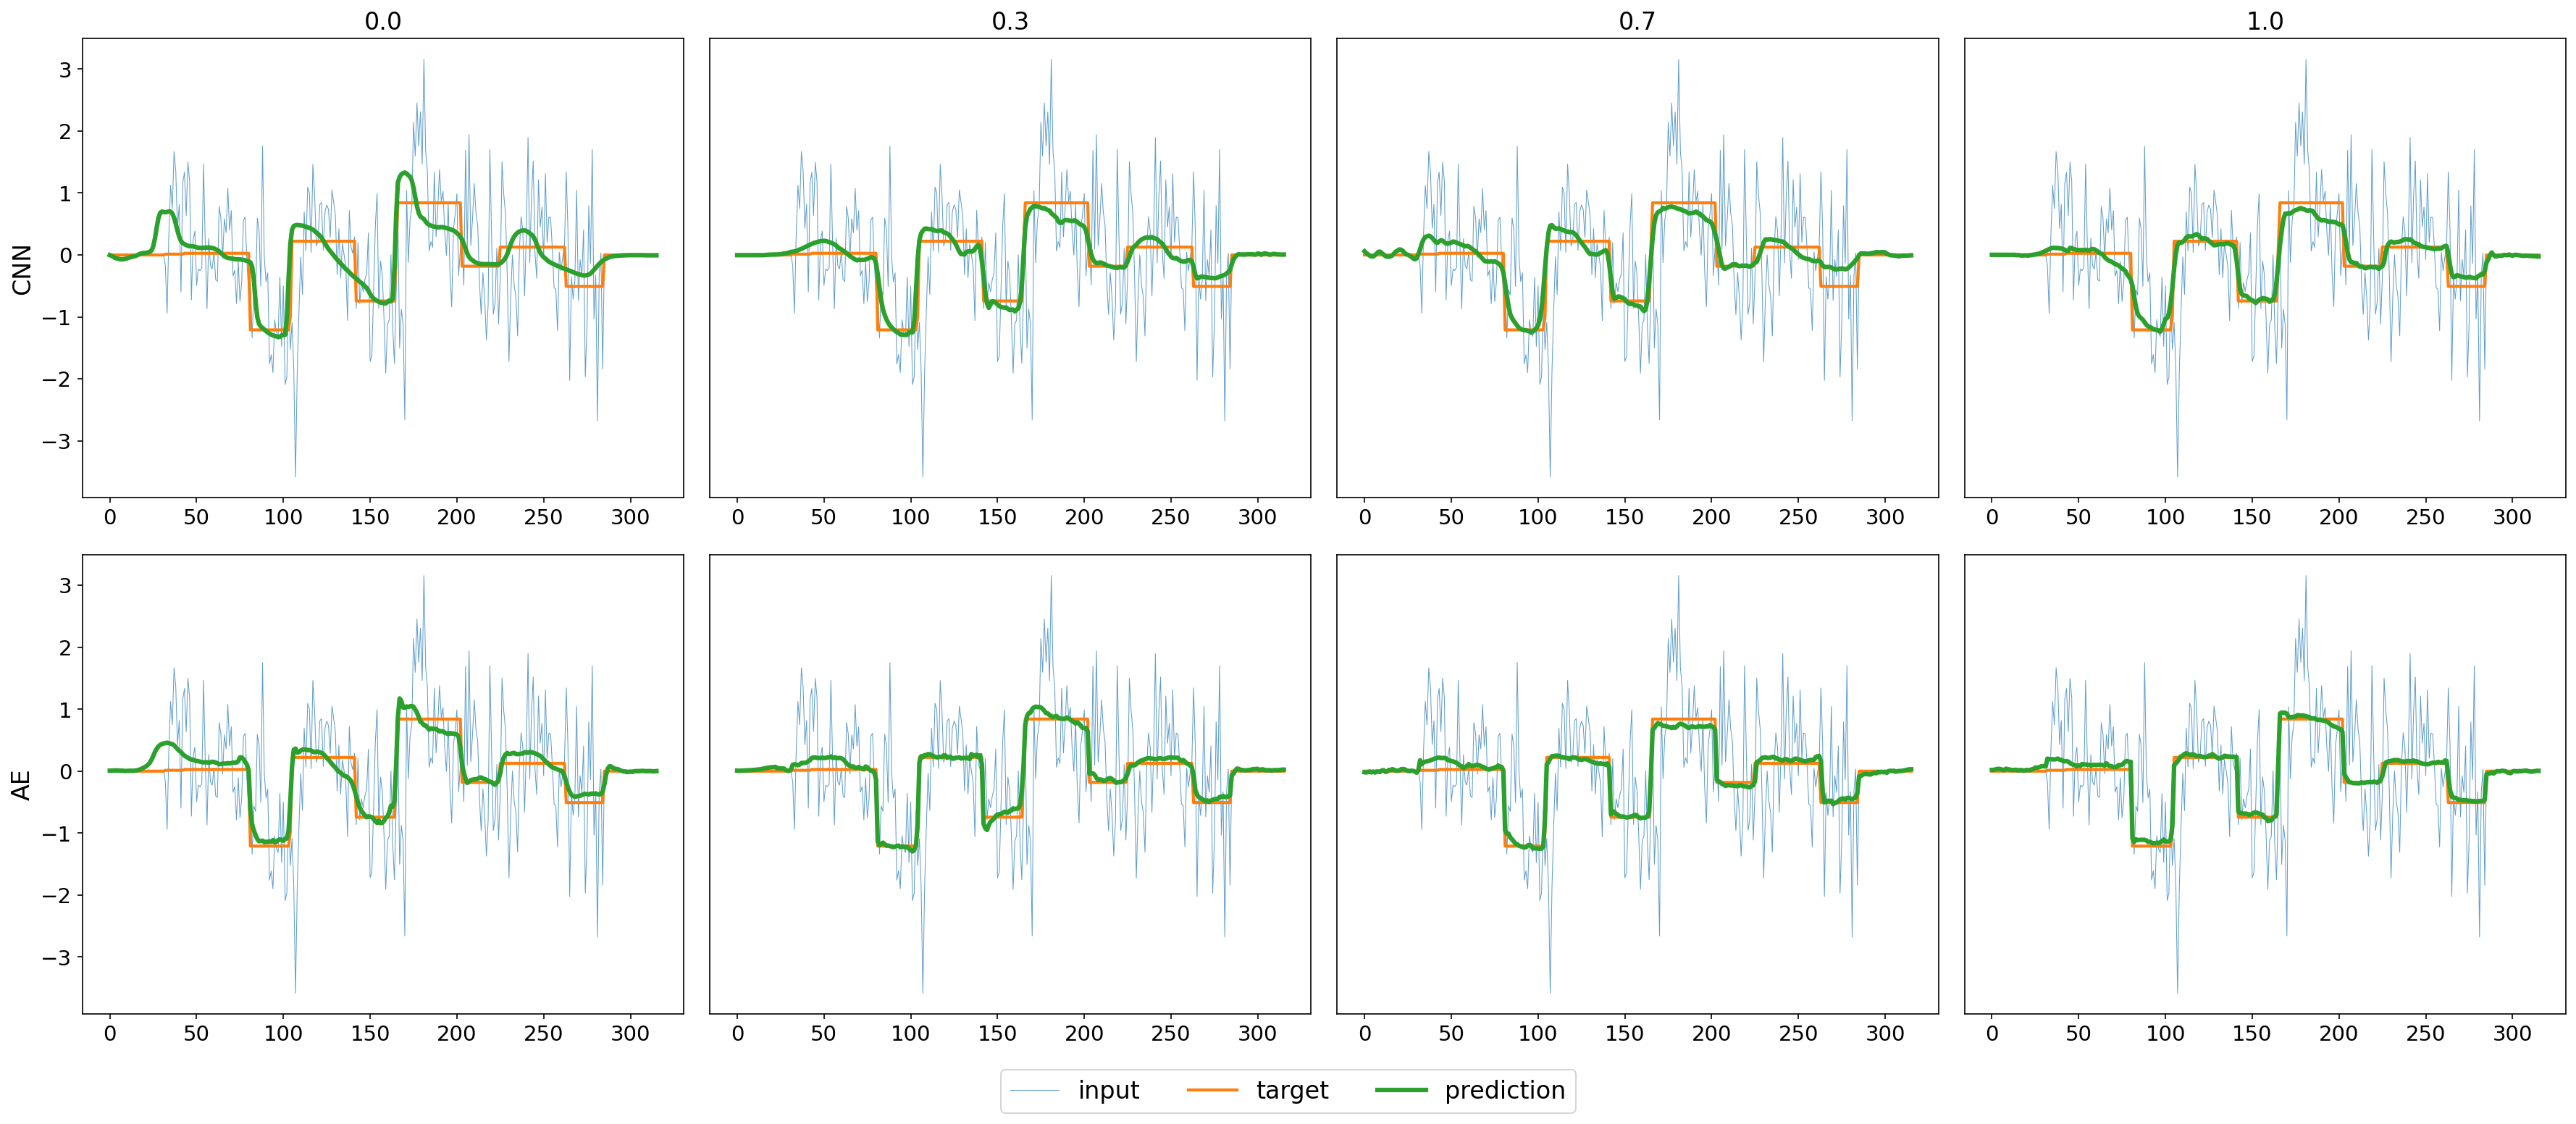

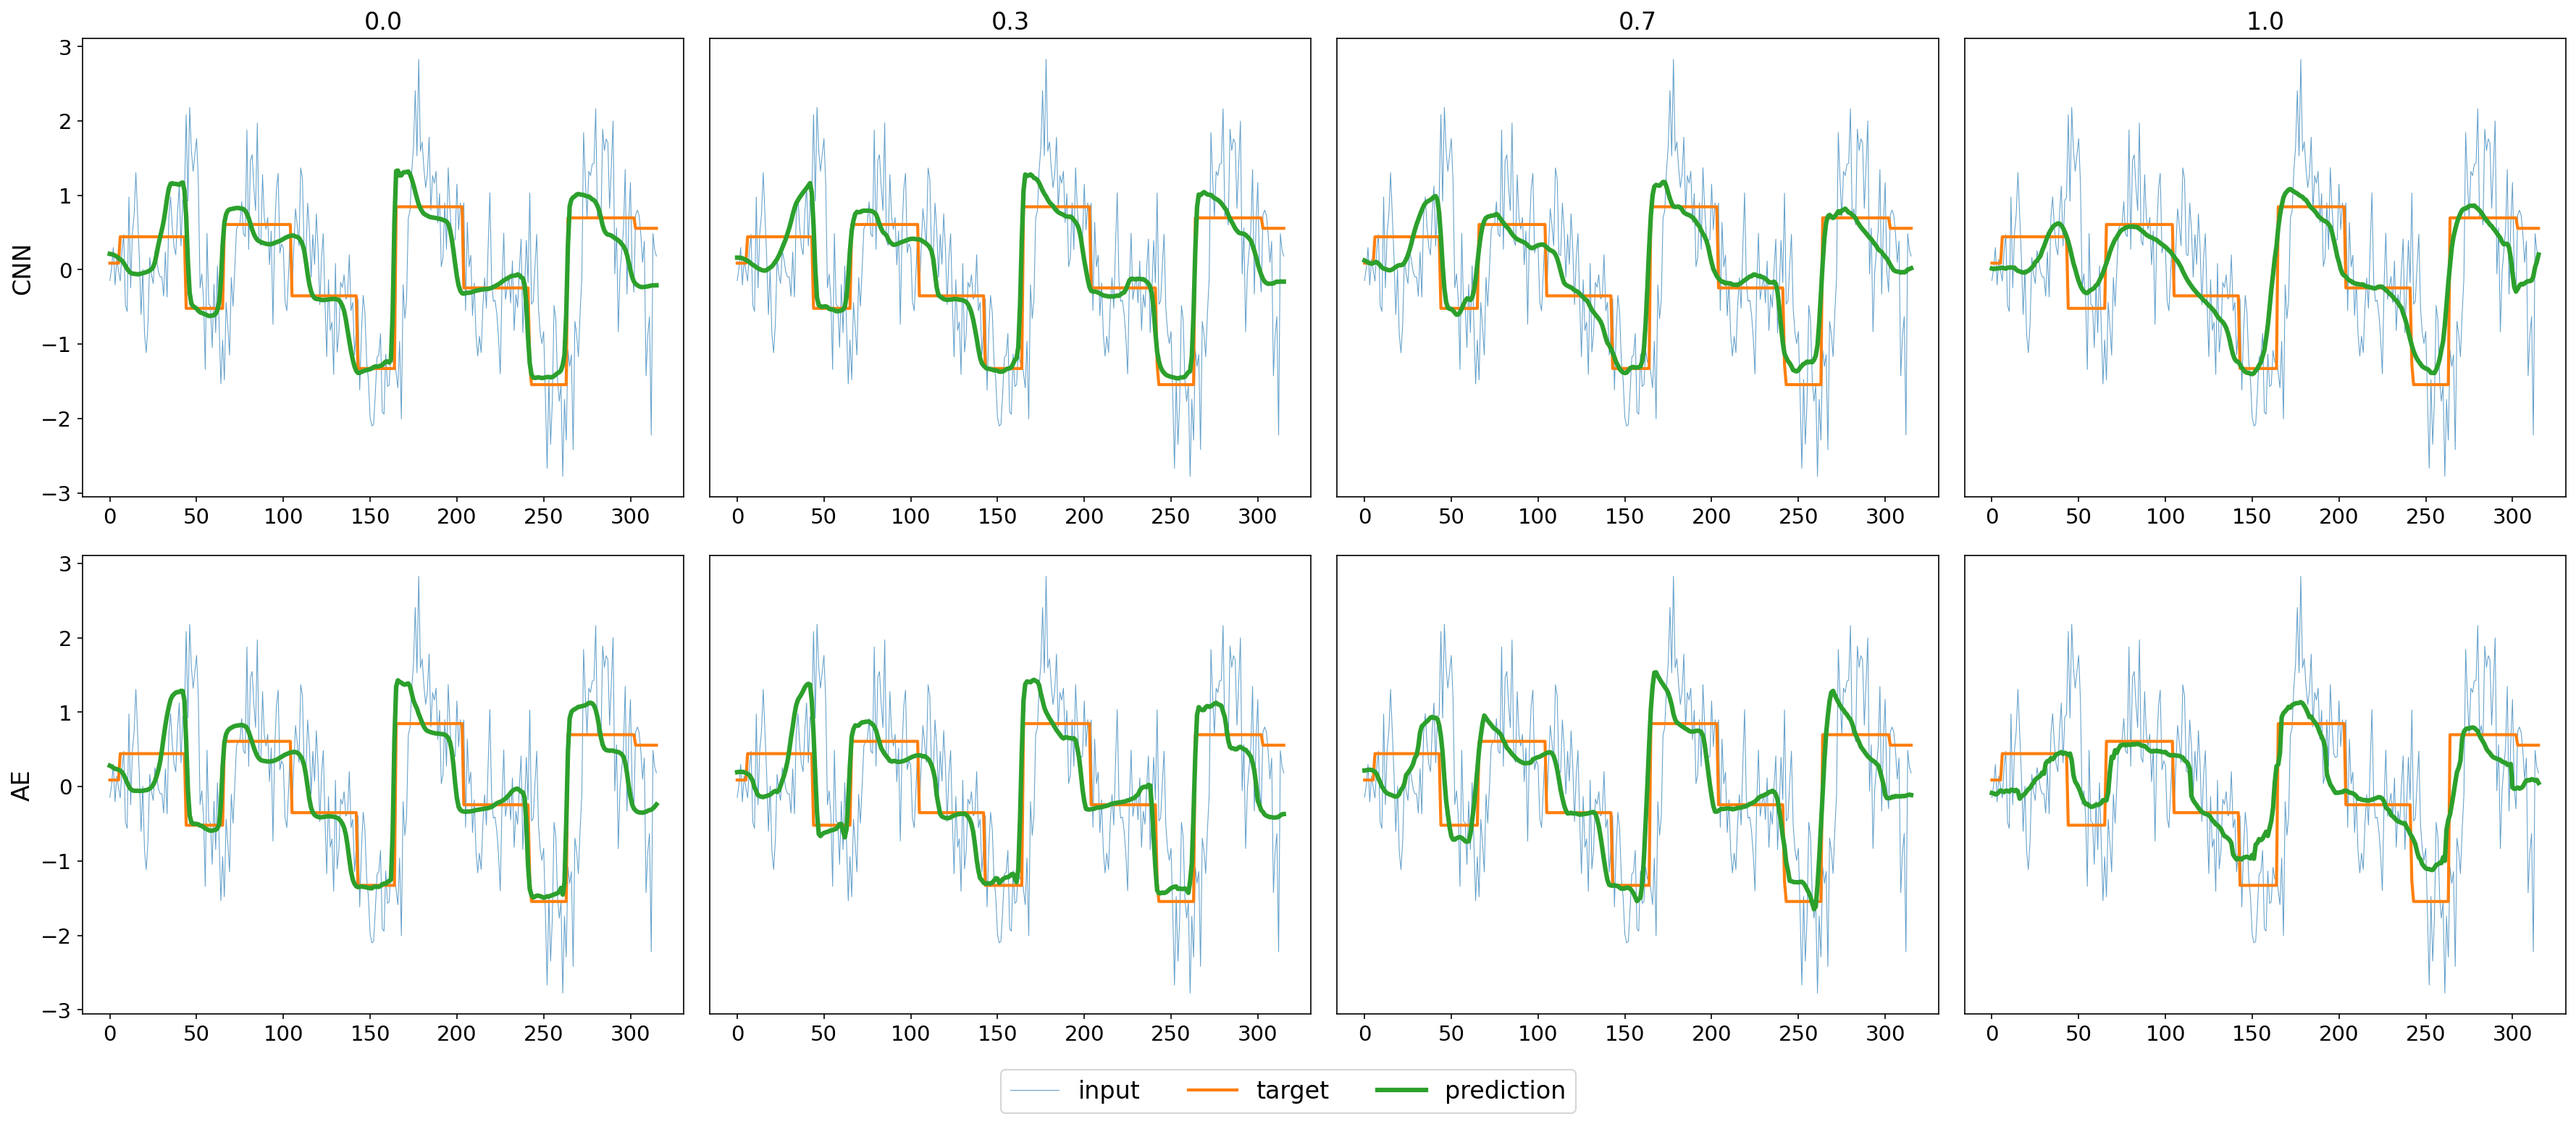

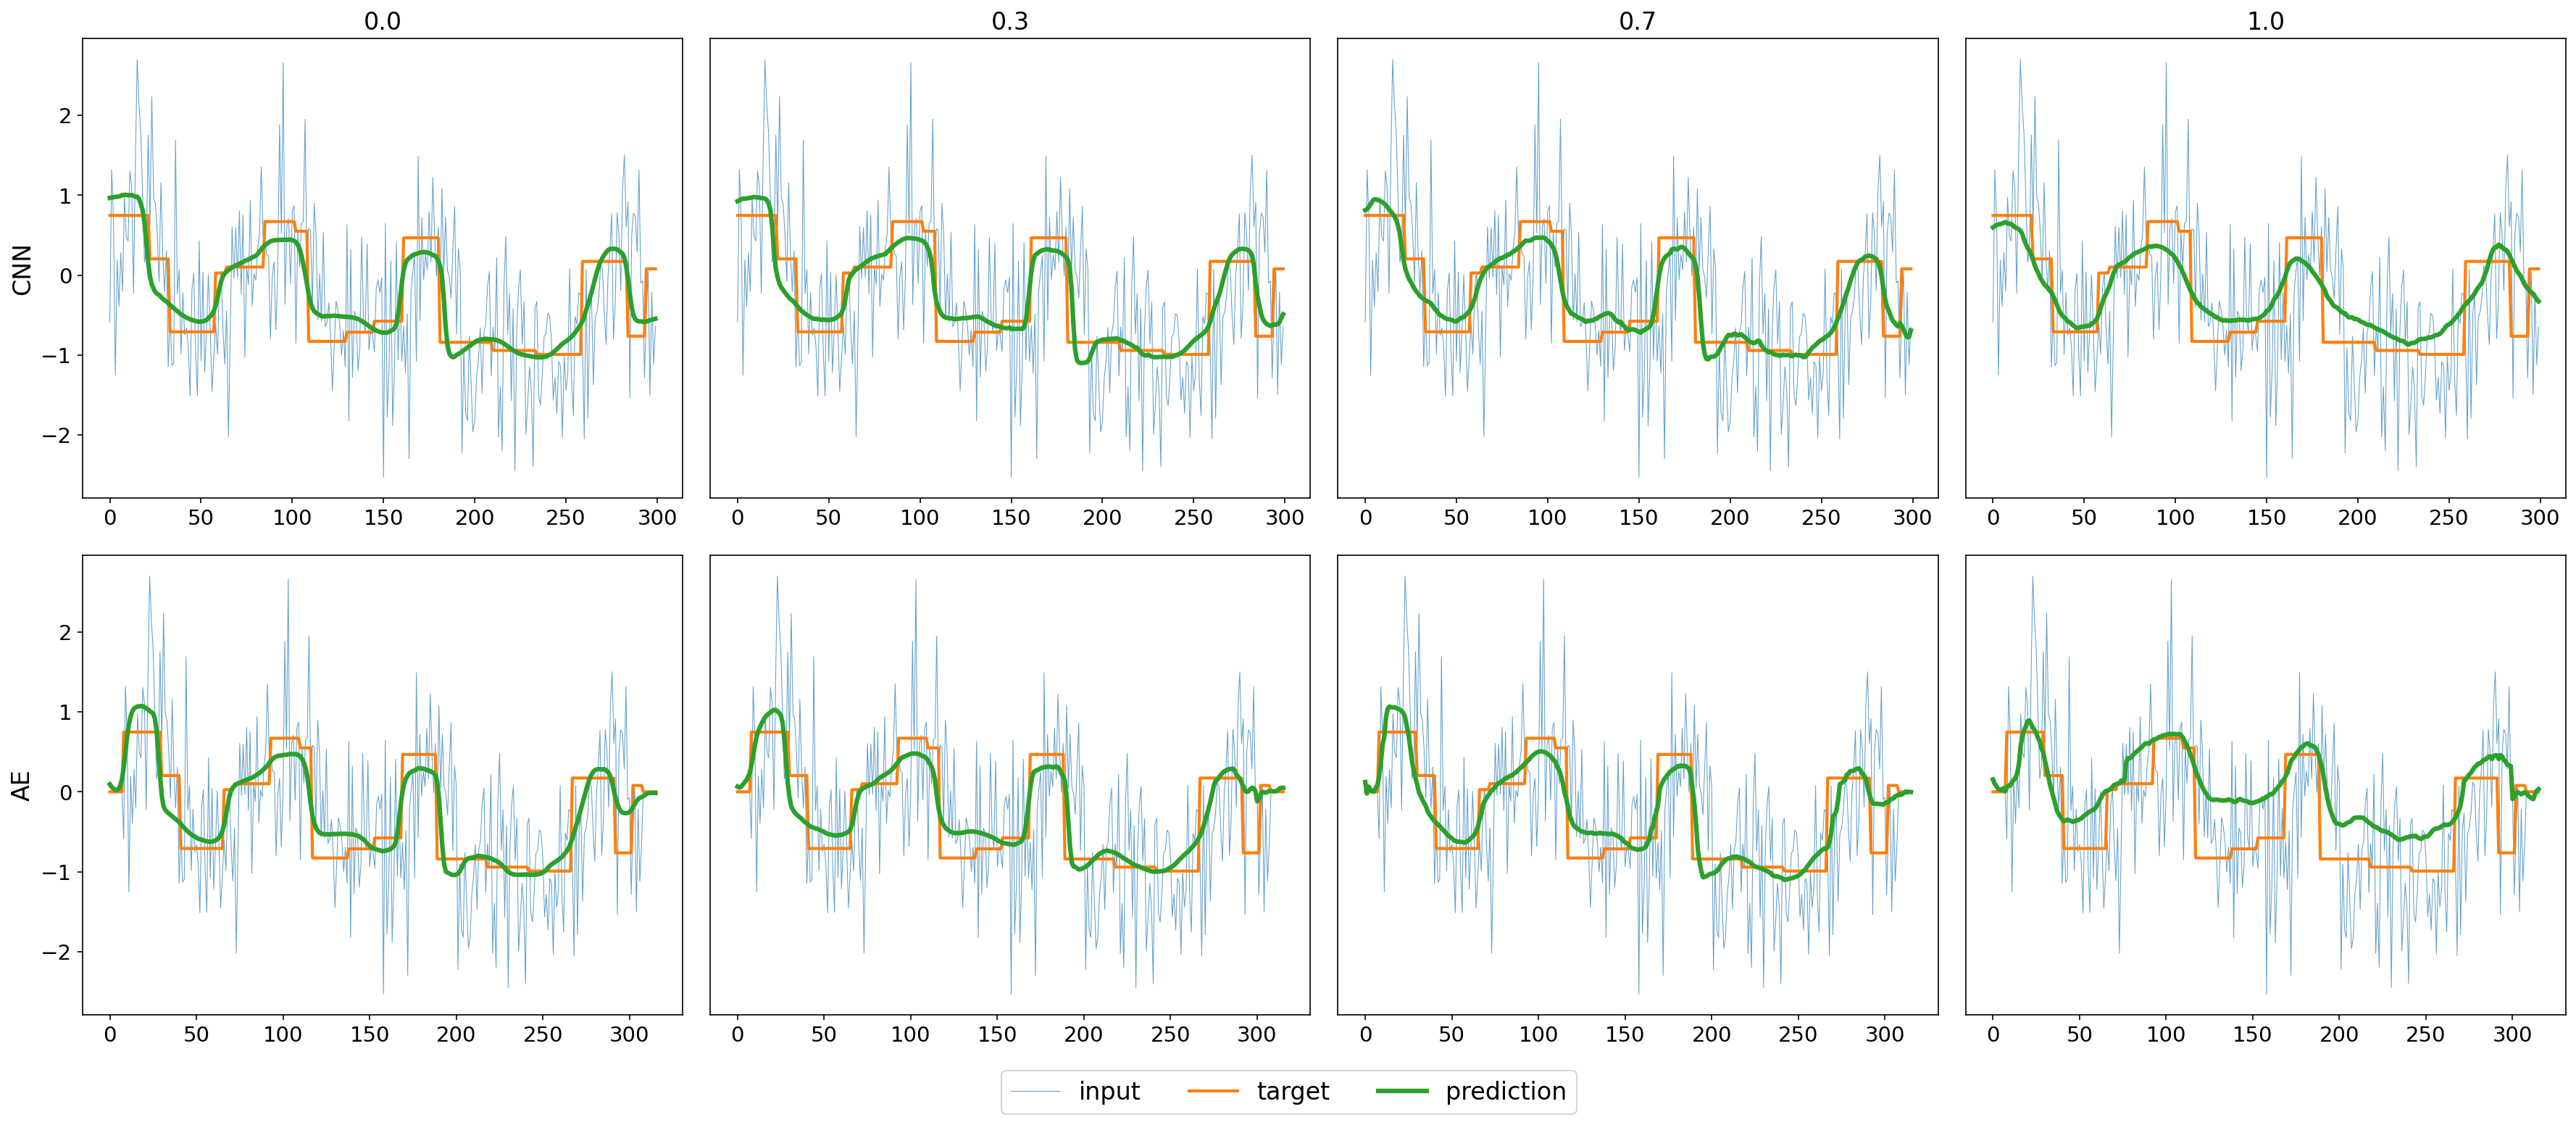

In [ ]:
def plot_sample_mixed_training(cnn_models_dict, ae_models_dict, dataset):

    fig, ax = plt.subplots(2, 4, figsize=(24, 10))
    input_plot_args = {'linewidth': 0.5, 'alpha': 0.7, 'label': 'input', 'c': 'tab:blue'}
    target_plot_args = {'linewidth': 2, 'label': 'target', 'c': 'tab:orange'}
    prediction_plot_args = {'linewidth': 3, 'label': 'prediction', 'c': 'tab:green'}

    v = np.random.randint(10000)
    X, y = dataset[v]
    X = X.unsqueeze(0).unsqueeze(-1)

    for i, key in enumerate(['0.0', '0.3', '0.7', '1.0']):

            cnn = cnn_models_dict[key].to('cpu')
            ae = ae_models_dict[key].to('cpu')

            prediction_cnn = cnn(X)
            prediction_cnn = prediction_cnn.detach().squeeze()
            ax[0, i].plot(X.squeeze(), **input_plot_args)
            ax[0, i].plot(y, **target_plot_args)
            ax[0, i].plot(prediction_cnn, **prediction_plot_args)

            padding = (ae.signal_length - X.shape[1]) / 2
            X_padded = F.pad(X, (0, 0, int(np.ceil(padding)), int(np.floor(padding))), mode='constant', value=0)
            y_padded = F.pad(y, (int(np.ceil(padding)), int(np.floor(padding))), mode='constant', value=0)
            _, _, prediction_ae = ae(X_padded)
            prediction_ae = prediction_ae.detach().squeeze()
            ax[1, i].plot(X_padded.squeeze(), **input_plot_args)
            ax[1, i].plot(y_padded, **target_plot_args)
            ax[1, i].plot(prediction_ae, **prediction_plot_args)

            ax[0, i].set_title(key)

    for i in range(1, 4):
        ax[0, i].set_yticks([], [])
        ax[1, i].set_yticks([], [])
    ax[0, 0].set_ylabel('CNN')
    ax[1, 0].set_ylabel('AE')

    handles, labels = ax[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), fontsize=16, ncol=len(handles))
    fig.tight_layout()

    return fig

f_gambling = plot_sample_mixed_training(models_dict_CNN, models_dict_AE, test_data['gambling'])
f_gambling.savefig('report_results/inference_mixed_gambling.png', bbox_inches='tight')

f_wm = plot_sample_mixed_training(models_dict_CNN, models_dict_AE, test_data['wm'])
f_wm.savefig('report_results/inference_mixed_wm.png', bbox_inches='tight')

f_simulated = plot_sample_mixed_training(models_dict_CNN, models_dict_AE, test_data['simulated'])
f_simulated.savefig('report_results/inference_mixed_simulated.png', bbox_inches='tight')

## CNN small

### Finetuning

In [6]:
def format_test_df(data_dict):
    renamed_dfs = []
    for key, df in data_dict.items():
        renamed = df.rename(columns={"metric": f"MSE ({key})", "var": f"var ({key})"})
        renamed_dfs.append(renamed)

    # Merge all dataframes on the 'model' column
    master_df = renamed_dfs[0]
    for df in renamed_dfs[1:]:
        master_df = master_df.merge(df, on="model", how="outer")
    
    master_df['pretraining_dataset'] = master_df['model'].str.contains('real').map({True: 'real', False: 'simulated'})
    master_df = master_df.sort_values(by='pretraining_dataset', ascending=True)
    master_df['model'] = master_df['model'].str.replace(r'\s*\(real\)', '', regex=True)
    master_df['model'] = master_df['model'].str.replace(r'\s*\(simulated\)', '', regex=True)
    master_df.set_index(['pretraining_dataset', 'model'], inplace=True)
    master_df.index.names = ['Pretraining dataset', 'Model']

    pairs = [
        ('MSE (simulated)', 'var (simulated)'),
        ('MSE (real)', 'var (real)'),
        ('MSE (motor)', 'var (motor)'),
        ('MSE (language)', 'var (language)'),
        ('MSE (gambling)', 'var (gambling)'),
        ('MSE (emotion)', 'var (emotion)'),
        ('MSE (wm)', 'var (wm)')
    ]

    # Overwrite MSE columns with formatted string
    for mse_col, var_col in pairs:
        master_df[mse_col] = master_df.apply(lambda row: f"{row[mse_col]:.4f} ± {row[var_col]:.4f}", axis=1)
    master_df = master_df.drop(columns=[var for _, var in pairs])

    return master_df

In [7]:
cnnsmall_FT_dict = pickle_load(f'final_models/cnn_small.pkl')

cnnsmall_test_df_dict = {}
for data_type, dataset in tqdm(test_data.items()):
    cnnsmall_test_df_dict[data_type] = compute_test_metric(cnnsmall_FT_dict, dataset, device="cpu")

formatted_cnnsmall_df = format_test_df(cnnsmall_test_df_dict)
formatted_cnnsmall_df.to_csv("report_results/cnnsmall_master_mse.csv")

100%|█████████████████████████████████████████████| 7/7 [00:59<00:00,  8.47s/it]


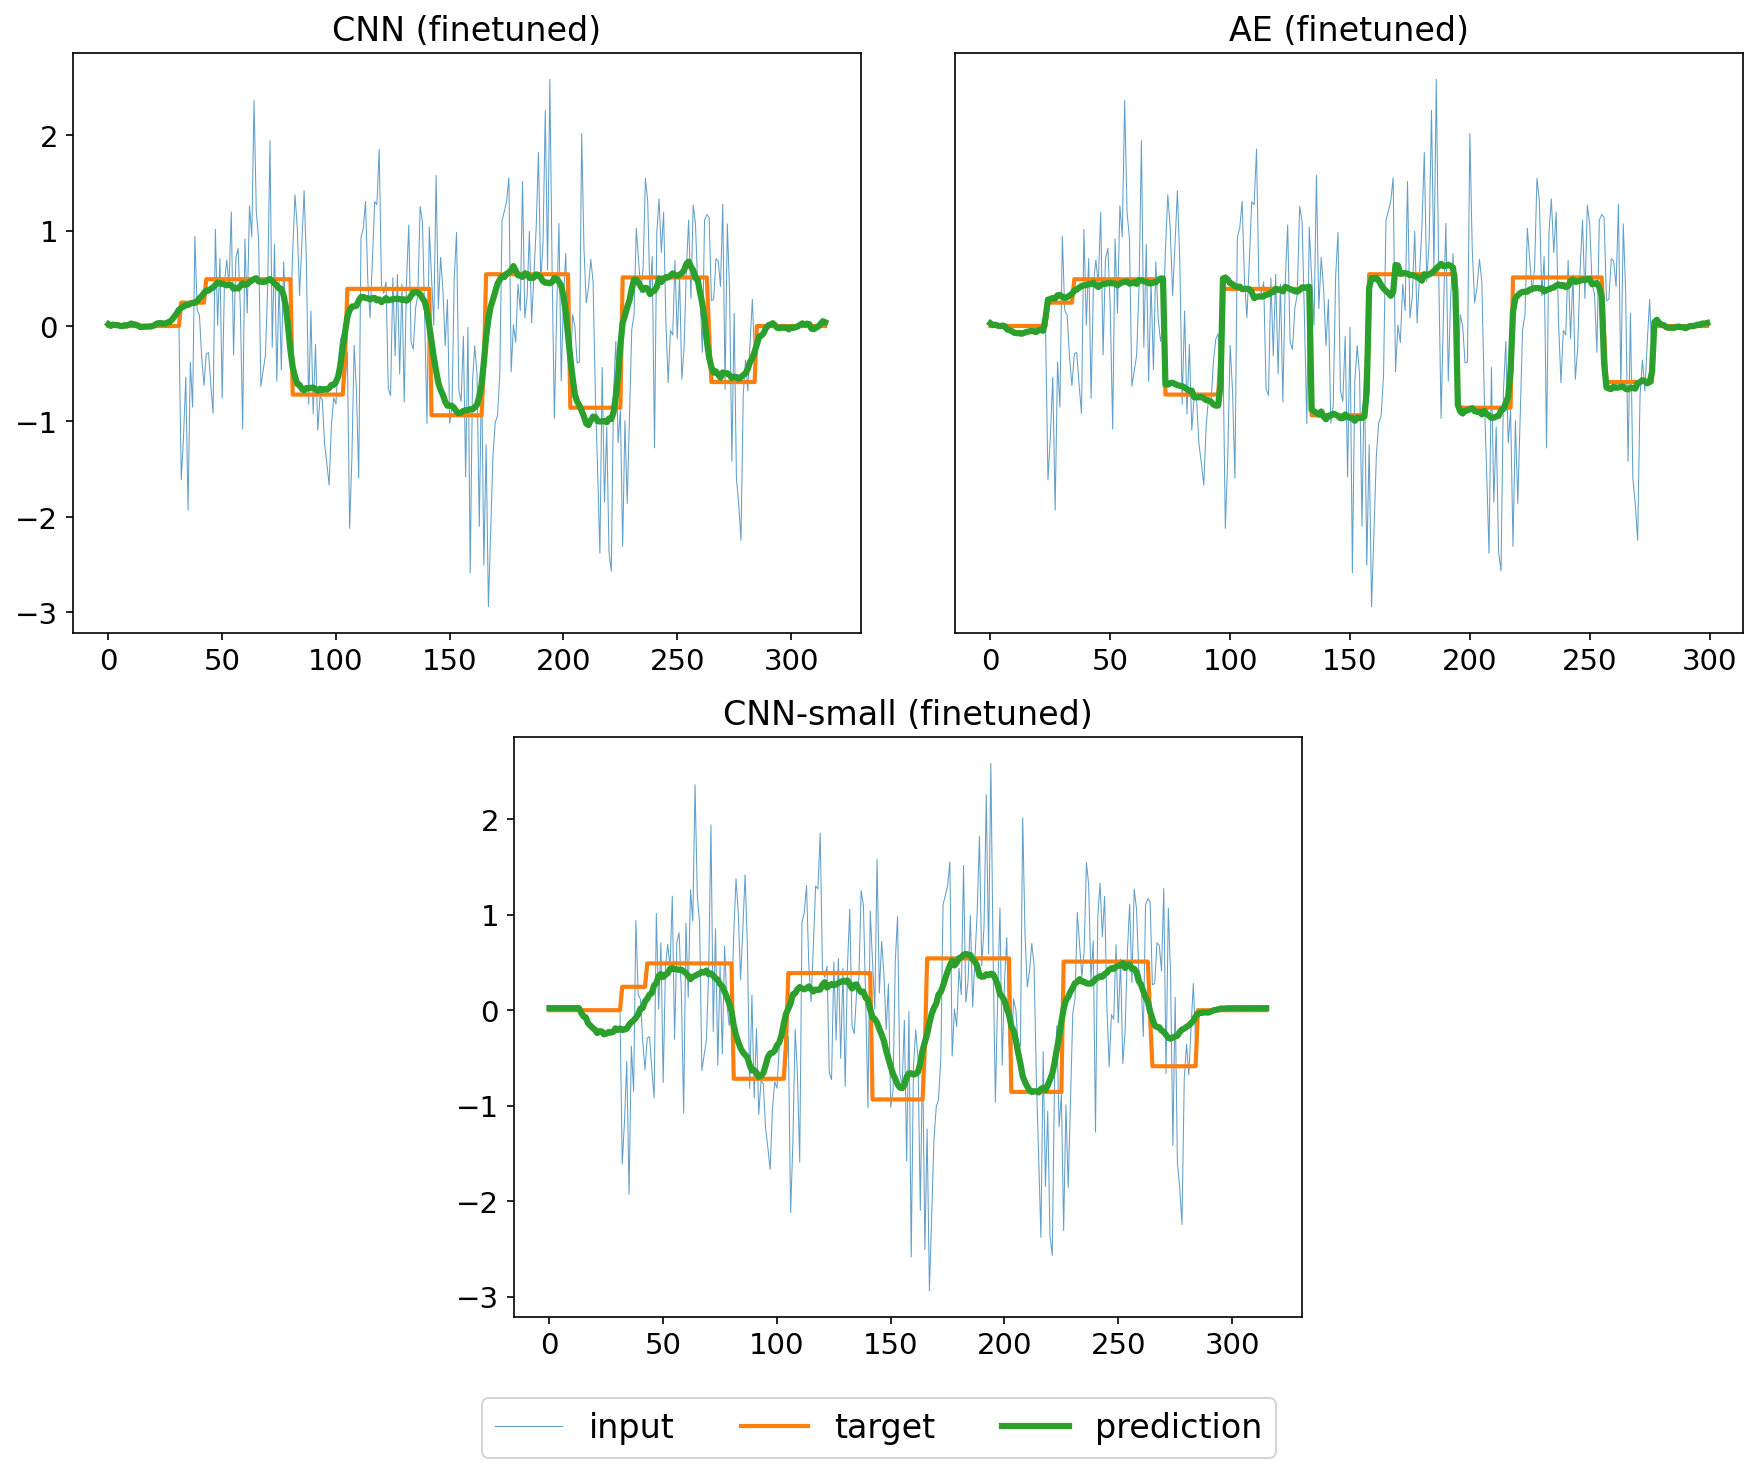

In [11]:
import matplotlib.gridspec as gridspec

# Load models
cnnsmall = pickle_load(f'final_models/cnn_small.pkl')['simulated_ft_lastlayer'][1].to('cpu')
cnn = pickle_load(f'final_models/cnn_finetuned.pkl')['simulated_ft_adapter2'][1].to('cpu')
ae = pickle_load(f'final_models/ae_finetuned.pkl')['simulated_ft_LDM'][1].to('cpu')

# Set up figure with a 2x3 grid
fig = plt.figure(figsize=(12, 10.5))
gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1])

# Top row: two plots
ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2:4])
# Bottom row: center plot in column 1 (middle column of 3)
ax2 = fig.add_subplot(gs[1, 1:3])

input_plot_args = {'linewidth': 0.5, 'alpha': 0.7, 'label': 'input', 'c': 'tab:blue'}
target_plot_args = {'linewidth': 2, 'label': 'target', 'c': 'tab:orange'}
prediction_plot_args = {'linewidth': 3, 'label': 'prediction', 'c': 'tab:green'}

v = np.random.randint(10000)
X, y = test_data['gambling'][v]
X = X.unsqueeze(0).unsqueeze(-1)

# CNN plot
prediction_cnn = cnn(X).detach().squeeze()
ax0.plot(X.squeeze(), **input_plot_args)
ax0.plot(y, **target_plot_args)
ax0.plot(prediction_cnn, **prediction_plot_args)
ax0.set_title('CNN (finetuned)')

# AE plot
padding = (ae.signal_length - X.shape[1]) / 2
X_padded = F.pad(X, (0, 0, int(np.ceil(padding)), int(np.floor(padding))), mode='constant', value=0)
y_padded = F.pad(y, (int(np.ceil(padding)), int(np.floor(padding))), mode='constant', value=0)
_, _, prediction_ae = ae(X_padded)
prediction_ae = prediction_ae.detach().squeeze()
ax1.plot(X_padded.squeeze(), **input_plot_args)
ax1.plot(y_padded, **target_plot_args)
ax1.plot(prediction_ae, **prediction_plot_args)
ax1.set_title('AE (finetuned)')
ax1.set_yticks([])

# CNN-small plot
prediction_cnnsmall = cnnsmall(X).detach().squeeze()
ax2.plot(X.squeeze(), **input_plot_args)
ax2.plot(y, **target_plot_args)
ax2.plot(prediction_cnnsmall, **prediction_plot_args)
ax2.set_title('CNN-small (finetuned)')

# Add legend
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.05), fontsize=16, ncol=len(handles))

fig.tight_layout()
fig.subplots_adjust(bottom=0.15)

fig.savefig('report_results/inference_cnnsmall.png', bbox_inches='tight')

### Mixed data training

In [30]:
models_dict_cnn_small = pickle_load('final_models/mixed_models_CNN_small.pkl')['models_dict']

In [ ]:
test_mse_dict = {'prop_real': [], 'mse_real': [], 'var_real': [], 'mse_sim': [], 'var_sim': [], 'mse_ood': [], 'var_ood': []}
for prop_real, model in tqdm(models_dict_cnn_small.items()):

    mse_real, var_real = test_model(test_loader_real, model)
    mse_sim, var_sim = test_model(test_loader_sim, model)
    mse_ood, var_ood = test_model(ood_loader, model)

    test_mse_dict['prop_real'].append(prop_real)
    test_mse_dict['mse_real'].append(mse_real)
    test_mse_dict['var_real'].append(var_real)
    test_mse_dict['mse_sim'].append(mse_sim)
    test_mse_dict['var_sim'].append(var_sim)
    test_mse_dict['mse_ood'].append(mse_ood)
    test_mse_dict['var_ood'].append(var_ood)

test_mse_df_AE = pd.DataFrame(test_mse_dict)
test_mse_df_AE.to_csv("report_results/mixed_mse_cnn_small.csv")

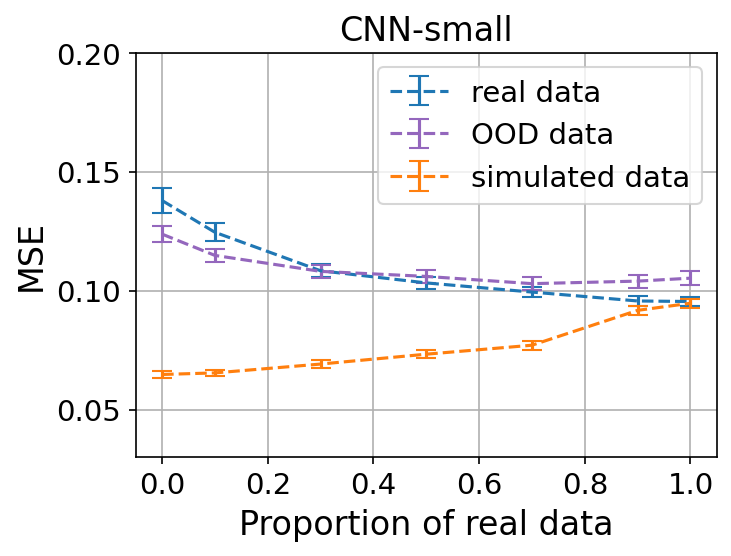

In [39]:
test_mse_df_small = pd.read_csv("report_results/mixed_mse_cnn_small.csv", index_col=[0])

f, ax = plt.subplots(figsize=(5, 3.5))
ax.errorbar(test_mse_df_small.prop_real, test_mse_df_small.mse_real, yerr=test_mse_df_small.var_real, capsize=5, label='real data', c='tab:blue', linestyle='--')
ax.errorbar(test_mse_df_small.prop_real, test_mse_df_small.mse_ood, yerr=test_mse_df_small.var_ood, capsize=5, label='OOD data', c='tab:purple', linestyle='--')
ax.errorbar(test_mse_df_small.prop_real, test_mse_df_small.mse_sim, yerr=test_mse_df_small.var_sim, capsize=5, label='simulated data', c='tab:orange', linestyle='--')
ax.set_xlabel('Proportion of real data')
ax.set_title(f'CNN-small')
ax.grid()
ax.set_ylim([0.03, 0.2])
ax.legend()

ax.set_ylabel('MSE')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

f.show()

f.savefig("report_results/mse_mixed_cnn_small.png", bbox_inches='tight')

# Appendix

In [33]:
results_df = pd.read_csv(f'csv_logs/cnn_logs_W9.csv')
# results_df = results_df.loc[results_df.study_name.str.contains('CNN_4L') & ~(results_df.study_name == 'CNN_4L_RealDataMGL_blocky=True_20250425_180925')]
results_df.study_name.unique()

array(['CNN_2l_SimDataALICE_blocky=True_20250414_160512',
       'CNN_3l_SimDataALICE_blocky=True_20250414_212532',
       'CNN_4l_SimDataALICE_blocky=True_20250415_224518',
       'CNN_2L_SimDataALICE_blocky=True_20250417_114201',
       'CNN_3L_SimDataALICE_blocky=True_20250418_025729',
       'CNN_4L_SimDataALICE_blocky=True_20250420_120840',
       'CNN_3L_RealDataMGL_blocky=True_20250423_153859',
       'CNN_3L_RealDataMGL_blocky=True_20250424_111908',
       'CNN_4L_RealDataMGL_blocky=True_20250425_180925',
       'CNN_4L_SimDataALICEO2_blocky=True_20250519_152253',
       'CNN_4L_SimDataALICEO2_blocky=True_20250525_212731'], dtype=object)

/tmp/ipykernel_1642016/4176514315.py:5: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_slice(study, params=['alpha', 'lambda_tv'], target_name='min. validation MSE')


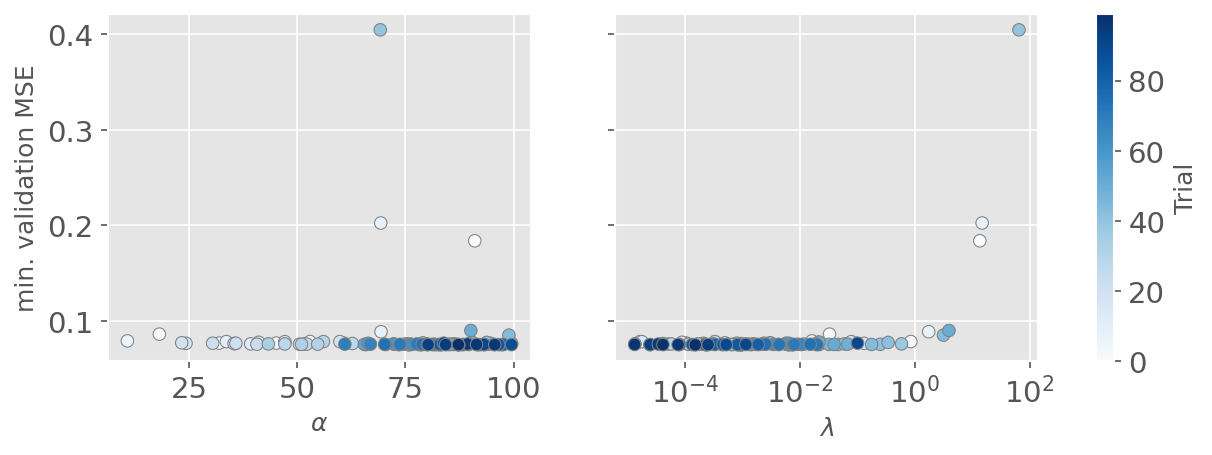

In [8]:
from optuna.visualization.matplotlib import plot_slice

study = pickle_load("optuna_logs/CNN_4L_SimDataALICE_blocky=True_20250420_120840")

ax = plot_slice(study, params=['alpha', 'lambda_tv'], target_name='min. validation MSE')
fig = plt.gcf()
ax[0].set_xlabel(r'$\alpha$')
ax[1].set_xlabel(r'$\lambda$')
fig.suptitle('', fontsize=16, x=0.435)
fig.set_size_inches(10, 3)

fig.savefig("report_results/loss_hp.png", bbox_inches='tight')